**1-Connexion à Google Drive**


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2-Extraction du dataset**


In [46]:
import zipfile
zip_path = '/content/drive/MyDrive/micro-club-pinktober-breast-cancer-detection.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/breast_cancer_detection')


**3-Vérification des répertoires du dataset**

In [47]:
import os
DATA = './breast_cancer_detection'
TRAIN= os.path.join(DATA, 'train')
print(f"Vérification de l'existence du DATA: {os.path.exists(DATA)}")
print(f"Vérification de l'existence du TRAIN: {os.path.exists(TRAIN)}")

Vérification de l'existence du DATA: True
Vérification de l'existence du TRAIN: True


**4-Importation des librairies nécessaires**


In [48]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

**5-Analyse exploratoire et vérification des données**

Nombre total d'images dans train : 700
Nombre total d'images dans test : 300
Total images: 700
Malignant (0): 350
Normal (1): 350

Valeurs manquantes dans test_df :
image_file    0
dtype: int64


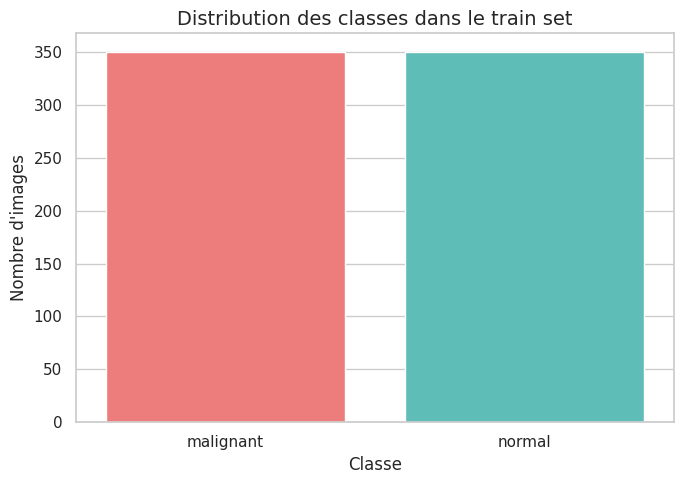

In [49]:
TRAIN = "./breast_cancer_detection/train"
TEST = "./breast_cancer_detection/test"
SUBMISSION_FILE = "submission.csv"
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.0001


num_train_files = sum([len(files) for r, d, files in os.walk(TRAIN)])
print(f"Nombre total d'images dans train : {num_train_files}")

num_test_files = sum([len(files) for r, d, files in os.walk(TEST )])
print(f"Nombre total d'images dans test : {num_test_files}")

data = []
for classe in ['malignant', 'normal']:
    class_path = os.path.join(TRAIN, classe)
    for filename in os.listdir(class_path):
        data.append({
            'filename': os.path.join(classe, filename),
            'label': 0 if classe == 'malignant' else 1,
            'class_name': classe
        })

df = pd.DataFrame(data)
print(f"Total images: {len(df)}")
print(f"Malignant (0): {len(df[df['label']==0])}")
print(f"Normal (1): {len(df[df['label']==1])}")

test_files = os.listdir(TEST)
test_df = pd.DataFrame({'image_file': test_files})
missing_test = test_df.isnull().sum()
print("\nValeurs manquantes dans test_df :")
print(missing_test)

import seaborn as sns
import matplotlib.pyplot as plt

if not df.empty:
    sns.set(style="whitegrid")
    plt.figure(figsize=(7, 5), dpi=100)
    plot = sns.countplot(x='class_name', data=df, hue='class_name',
                  palette={'malignant':'#FF6B6B', 'normal':'#4ECDC4'},
                  order=['malignant', 'normal'],
                  dodge=False)

    plt.title("Distribution des classes dans le train set", fontsize=14)
    plt.xlabel("Classe", fontsize=12)
    plt.ylabel("Nombre d'images", fontsize=12)
    if plot.get_legend() is not None:
        plot.get_legend().remove()

    plt.tight_layout()
    plt.show()
else:
    print(" ERREUR : Le DataFrame est vide. Aucune image n'a été trouvée dans les dossiers d'entraînement.")

**6-Préparation des datasets et augmentation des données**

In [44]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN ,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN ,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)
class_names = train_ds.class_names
print(f"Noms de classes trouvés (Index 0/1): {class_names}")

def map_to_submission_label(index):
    if class_names[index].lower() == 'malignant':
        return 'M'
    elif class_names[index].lower() == 'normal':
        return 'N'
    return '?'


data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),  # Seulement horizontal
    layers.RandomRotation(0.1),  # Rotation légère (±10% = ±36°)
    layers.RandomZoom(0.1),  # Zoom léger
    layers.RandomContrast(0.15),  # Contraste modéré
], name="data_augmentation")

def preprocess_and_augment(image, label):
    image = data_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def preprocess_only(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 700 files belonging to 2 classes.
Using 560 files for training.
Found 700 files belonging to 2 classes.
Using 140 files for validation.
Noms de classes trouvés (Index 0/1): ['malignant', 'normal']


**7-Construction et compilation du modèle MobileNetV2**

In [50]:
base_model = MobileNetV2(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)  # Ajout d'une couche dense
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)  # Deuxième couche dense
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)


model = Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

/tmp/ipython-input-455175049.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**8-Entraînement du modèle (Phase 1 : Base figée)**

In [51]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,  # Augmenté de 7 à 10
        restore_best_weights=True
    ),
    reduce_lr
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 896ms/step - accuracy: 0.4920 - loss: 0.7901 - val_accuracy: 0.4929 - val_loss: 0.6997 - learning_rate: 1.0000e-04
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 851ms/step - accuracy: 0.5130 - loss: 0.7324 - val_accuracy: 0.4786 - val_loss: 0.6910 - learning_rate: 1.0000e-04
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 883ms/step - accuracy: 0.5221 - loss: 0.7424 - val_accuracy: 0.5714 - val_loss: 0.6862 - learning_rate: 1.0000e-04
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 840ms/step - accuracy: 0.5576 - loss: 0.7196 - val_accuracy: 0.5214 - val_loss: 0.6865 - learning_rate: 1.0000e-04
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 831ms/step - accuracy: 0.4912 - loss: 0.7084 - val_accuracy: 0.5286 - val_loss: 0.6922 - learning_rate: 1.0000e-04
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.5647 - loss: 0.6909
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 831ms/step - accuracy:

**9-Affinage du modèle (Stage 2 : Fine-Tuning)**

In [52]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
     optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
     loss='binary_crossentropy',
     metrics=['accuracy']
 )
history_ft = model.fit(
     train_ds,
    epochs=EPOCHS + 5,
     initial_epoch=history.epoch[-1],
     validation_data=val_ds,
     callbacks=callbacks
 )


Epoch 13/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5049 - loss: 0.7383 - val_accuracy: 0.5643 - val_loss: 0.6856 - learning_rate: 1.0000e-05
Epoch 14/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5037 - loss: 0.7300 - val_accuracy: 0.5786 - val_loss: 0.6840 - learning_rate: 1.0000e-05
Epoch 15/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5085 - loss: 0.7201 - val_accuracy: 0.5786 - val_loss: 0.6830 - learning_rate: 1.0000e-05
Epoch 16/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.4545 - loss: 0.7444 - val_accuracy: 0.5643 - val_loss: 0.6821 - learning_rate: 1.0000e-05
Epoch 17/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4555 - loss: 0.7448 - val_accuracy: 0.5929 - val_loss: 0.6821 - learning_rate: 1.0000e-05
Epoch 18/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5402 - loss: 0.7187 - val_accuracy: 0.5857 - val_loss: 0.6819 - learning_rate: 1.0000e-05
Epoch 19/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5705 

**10-Prédiction sur le jeu de test**

In [53]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST,
    labels=None,
    shuffle=False,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)
test_filenames = test_ds.file_paths
test_filenames = [os.path.basename(f) for f in test_filenames]
test_ds = test_ds.map(lambda image: preprocess_input(image), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
print("Exécution des prédictions sur l'ensemble de test")
raw_predictions = model.predict(test_ds)
predicted_indices = (raw_predictions > 0.5).astype(int)
submission_labels = [map_to_submission_label(i[0]) for i in predicted_indices]

Found 300 files.
Exécution des prédictions sur l'ensemble de test
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 676ms/step


**11-Création du fichier de soumission**

In [54]:
submission_df = pd.DataFrame({
    'image file': test_filenames,
    'label': submission_labels
})
submission_df.to_csv("submission.csv", index=False)
print(f"SUCCÈS ! Fichier de soumission créé: {SUBMISSION_FILE}")
print(submission_df.head(10))

SUCCÈS ! Fichier de soumission créé: submission.csv
   image file label
0  101837.jpg     M
1  102480.jpg     N
2  105295.jpg     M
3  107574.jpg     M
4  113739.jpg     N
5   11652.jpg     M
6  116761.jpg     N
7  123047.jpg     M
8  132435.jpg     M
9  134255.jpg     N


**12-Configuration de l’API Kaggle**

In [34]:
!pip install -q kaggle
print(" Librairie Kaggle installée.")
from google.colab import files
print("\nVeuillez sélectionner votre fichier 'kaggle.json' :")
uploaded = files.upload()
KAGGLE_FILE = "kaggle (1).json"
KAGGLE_DEST_NAME = "kaggle.json"
!mkdir -p ~/.kaggle
!cp "{KAGGLE_FILE}" ~/.kaggle/"{KAGGLE_DEST_NAME}"
!chmod 600 ~/.kaggle/"{KAGGLE_DEST_NAME}"
print(" Configuration Kaggle terminée (Clé copiée et permissions ajustées).")

 Librairie Kaggle installée.

Veuillez sélectionner votre fichier 'kaggle.json' :


Saving kaggle (1).json to kaggle (1) (2).json
 Configuration Kaggle terminée (Clé copiée et permissions ajustées).


**13-Soumission du fichier sur Kaggle**

In [55]:
!kaggle competitions submit -c micro-club-pinktober-breast-cancer-detection -f submission.csv -m "submission"

100% 3.80k/3.80k [00:00<00:00, 8.97kB/s]
Successfully submitted to Micro Club Pinktober: Breast Cancer Detection